In [15]:
import pandas as pd
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.ml.regression import DecisionTreeRegressor, RandomForestRegressor, GBTRegressor

import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PATH'] = os.environ['JAVA_HOME'] + '/bin:' + os.environ['PATH']


df = pd.read_csv('etreproprio_rhone_propre.csv', encoding='utf-8-sig')

In [16]:

df = pd.read_csv('etreproprio_rhone_propre.csv', encoding='utf-8-sig')
print(f"Nombre d'annonces : {len(df)}")
print(f"Colonnes : {list(df.columns)}")
df.head(3)

Nombre d'annonces : 578
Colonnes : ['titre', 'description', 'ville', 'type_bien', 'etage', 'prix', 'surface', 'pieces', 'DPE', 'full_description', 'lien']


,titre,description,ville,type_bien,etage,prix,surface,pieces,DPE,full_description,lien
0,Vente Appartement 72 m2 Francheville,Appartement 72 m2 à Francheville,francheville,Appartement,1,269000.0,72.0,3.0,D,Decultieux Immobililer la référence depuis 196...,https://www.etreproprio.com/immobilier-2529512...
1,Vente Appartement 78 m2 Villeurbanne,Appartement 78 m2 à Villeurbanne,villeurbanne,Appartement,3,293000.0,78.0,4.0,C,Une exclusivité DECULTIEUX Immobilier\nVILLEUR...,https://www.etreproprio.com/immobilier-2529512...
2,Vente Appartement 208 m2 Feyzin,EXCLUSIVITÉ Feyzin La Bégude Appartement r...,feyzin,Appartement,0,380000.0,208.0,5.0,A,FEYZIN LA BÉGUDE Le confort d’une maison réc...,https://www.etreproprio.com/immobilier-2529551...


In [17]:

STOPWORDS = {
    'le','la','les','de','du','des','un','une','en','et','à','au','aux',
    'est','sont','se','sa','son','ses','sur','par','pour','dans','avec',
    'ce','cette','ces','qui','que','qu','il','elle','ils','elles','on',
    'nous','vous','tout','plus','très','ou','y','ne','pas','vous','si',
    'bien','être','avoir','fait','été','comme','dont','mais','aussi','entre',
    'leur','leurs','votre','notre','nos','vos','has','the','a','an','of',
    'its','from','this','that','to','is','in','at','be','as','are','was',
    'd','l','n','s','m','j','c','y','qu','jusqu','lorsqu'
}

def nettoyer_texte(texte):
    
    if not isinstance(texte, str):
        return []
    texte = texte.lower()
    texte = re.sub(r'[^a-zàâäéèêëîïôùûüç\s]', ' ', texte)
    mots = texte.split()
    
    mots = [m for m in mots if len(m) > 3 and m not in STOPWORDS]
    return mots

print("Exemple de nettoyage sur la 1ère annonce :")
print(nettoyer_texte(df['full_description'].iloc[0])[:20])

Exemple de nettoyage sur la 1ère annonce :
['decultieux', 'immobililer', 'référence', 'depuis', 'propose', 'exclusivité', 'francheville', 'duplex', 'dernier', 'étage', 'immeuble', 'récent', 'dégagée', 'monts', 'lyonnais', 'appartement', 'agréable', 'vivre', 'calme', 'lumineux']


In [18]:

def groupByKey(data):
    
    result = dict()
    for key, value in data:
        if key in result:
            result[key].append(value)
        else:
            result[key] = [value]
    return result

def reduceByKey(f, data):
    key_values = groupByKey(data)
    return map(lambda key: (key, reduce(f, key_values[key])), key_values)


In [19]:

descriptions = df['full_description'].dropna().tolist()
print(f"Nombre de descriptions non nulles : {len(descriptions)}")


mapped = []
for desc in descriptions:
    mots = nettoyer_texte(desc)
    paires = list(map(lambda word: (word, 1), mots))  # ← map() du cours
    mapped.extend(paires)

print(f"Nombre total de paires (mot, 1) produites : {len(mapped):,}")
print("Exemples de paires :", mapped[:10])

Nombre de descriptions non nulles : 578
Nombre total de paires (mot, 1) produites : 74,926
Exemples de paires : [('decultieux', 1), ('immobililer', 1), ('référence', 1), ('depuis', 1), ('propose', 1), ('exclusivité', 1), ('francheville', 1), ('duplex', 1), ('dernier', 1), ('étage', 1)]


In [20]:

wordcount = list(reduceByKey(lambda x, y: x + y, mapped))

wordcount_sorted = sorted(wordcount, key=lambda x: x[1], reverse=True)

print(f"Nombre de mots distincts : {len(wordcount_sorted):,}")
print("\nTop 20 mots les plus fréquents dans les descriptions :")
for mot, count in wordcount_sorted[:20]:
    print(f"  {mot:<25} {count:>6}")



Nombre de mots distincts : 5,275

Top 20 mots les plus fréquents dans les descriptions :
  appartement                  797
  salle                        725
  espace                       609
  lyon                         595
  cuisine                      549
  chambres                     501
  maison                       491
  informations                 482
  copropriété                  474
  étage                        439
  sous                         411
  résidence                    388
  coordonnées                  381
  masquées                     381
  situé                        379
  deux                         366
  exposé                       363
  calme                        360
  pièce                        359
  proximité                    355


In [23]:
def top_k_mots(wordcount_sorted, k=30):
    return wordcount_sorted[:k]

k = 30
top30 = top_k_mots(wordcount_sorted, k)

print(f"Top {k} mots les plus fréquents dans les annonces immobilières du Rhône :")
for i, (mot, count) in enumerate(top30, 1):
    print(f"  {i:>2}. {mot:<25} {count:>6} occurrences")

Top 30 mots les plus fréquents dans les annonces immobilières du Rhône :
   1. appartement                  797 occurrences
   2. salle                        725 occurrences
   3. espace                       609 occurrences
   4. lyon                         595 occurrences
   5. cuisine                      549 occurrences
   6. chambres                     501 occurrences
   7. maison                       491 occurrences
   8. informations                 482 occurrences
   9. copropriété                  474 occurrences
  10. étage                        439 occurrences
  11. sous                         411 occurrences
  12. résidence                    388 occurrences
  13. coordonnées                  381 occurrences
  14. masquées                     381 occurrences
  15. situé                        379 occurrences
  16. deux                         366 occurrences
  17. exposé                       363 occurrences
  18. calme                        360 occurrences
  19. piè

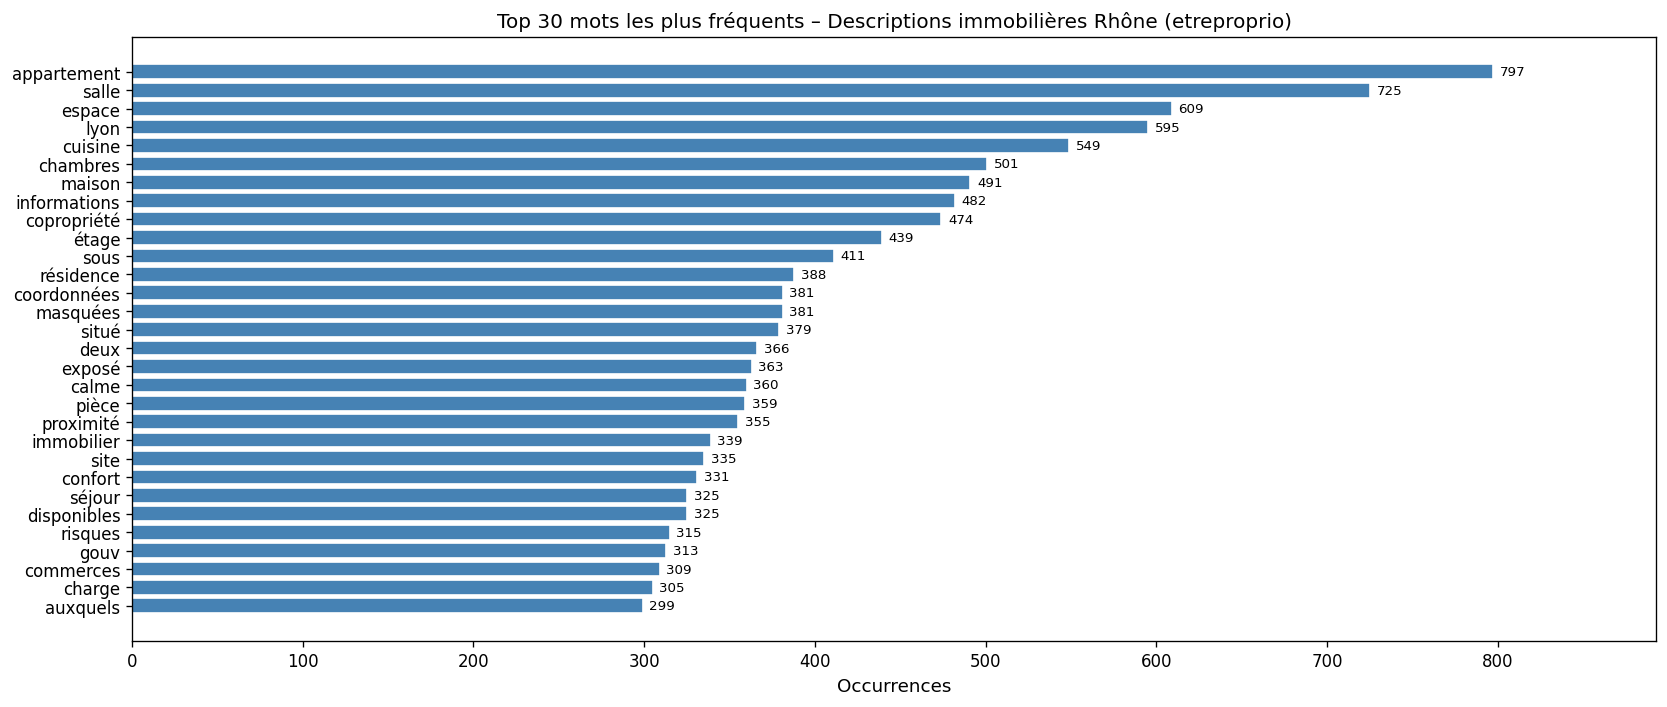

Graphique sauvegardé : wordcount_immo.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

mots_plot  = [m for m, _ in top30]
counts_plot = [c for _, c in top30]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(mots_plot[::-1], counts_plot[::-1], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=8)
ax.set_xlabel('Occurrences', fontsize=11)
ax.set_title(f'Top {k} mots les plus fréquents – Descriptions immobilières Rhône (etreproprio)', fontsize=12)
ax.set_xlim(0, max(counts_plot) * 1.12)
plt.tight_layout()
plt.savefig('wordcount_immo.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : wordcount_immo.png")